DATOS CARGADOS
Shape: (160, 192, 64)
Suavizado aplicado.


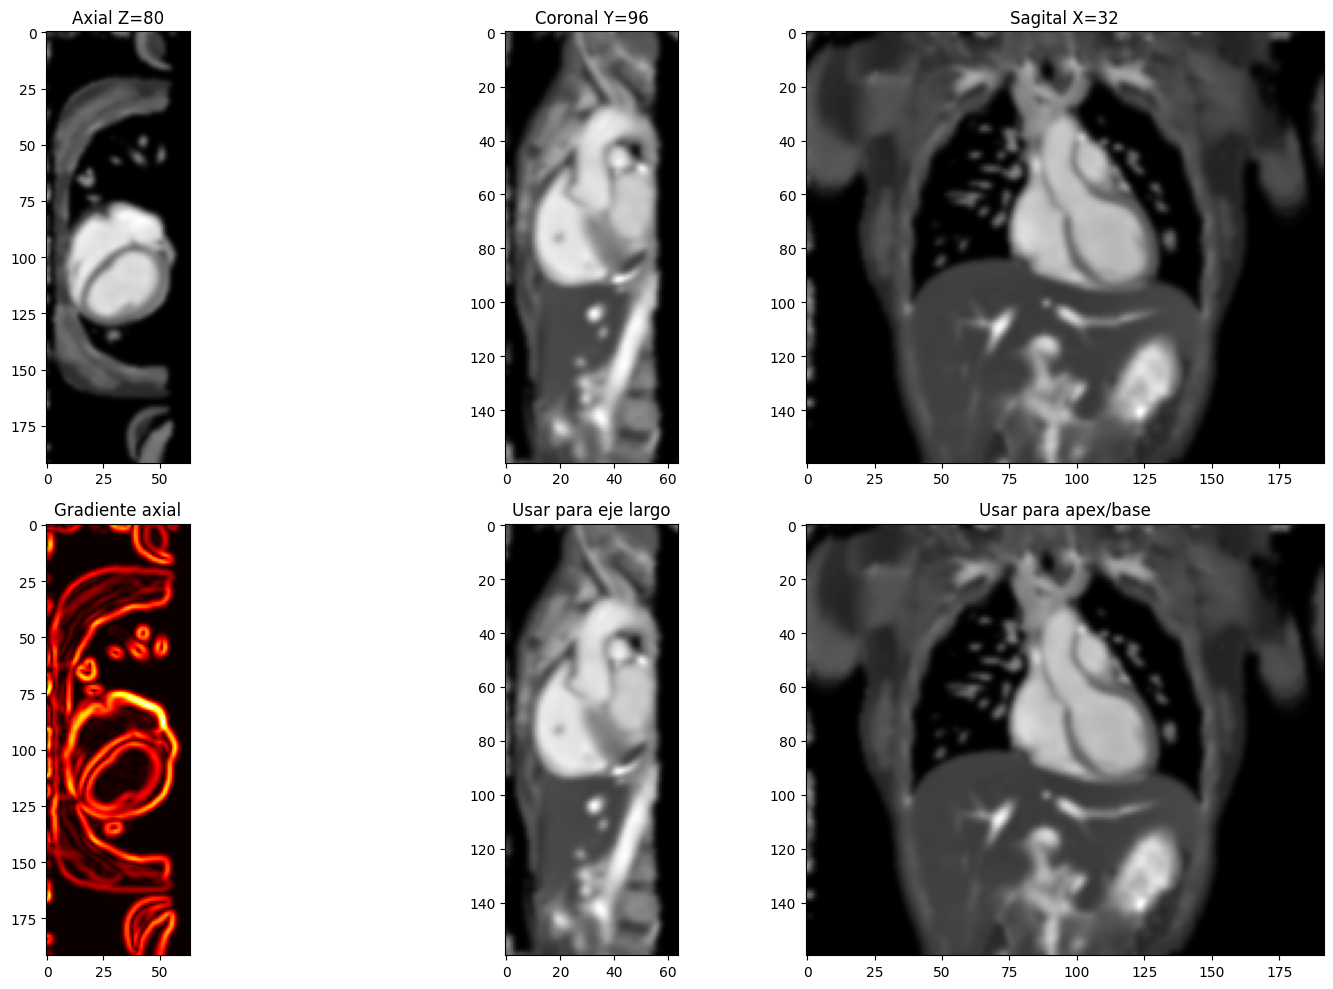

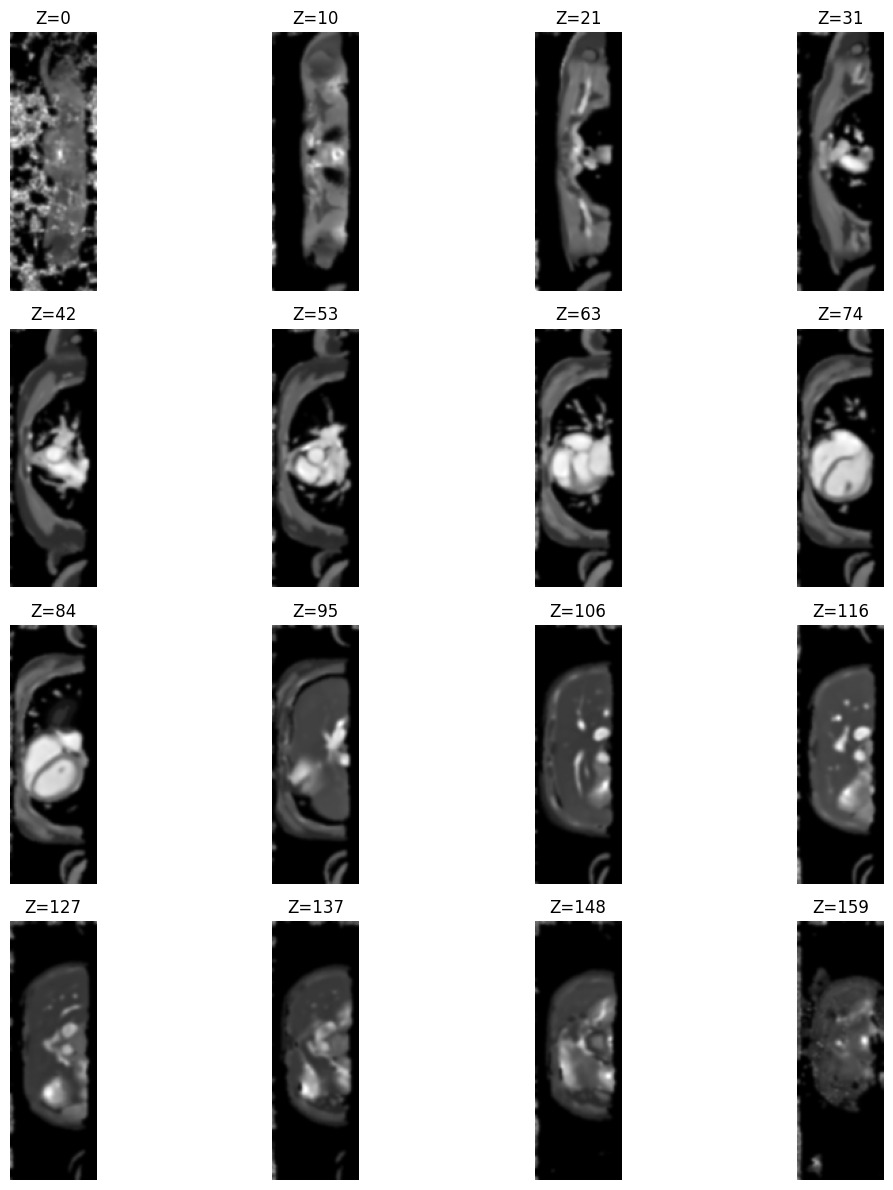

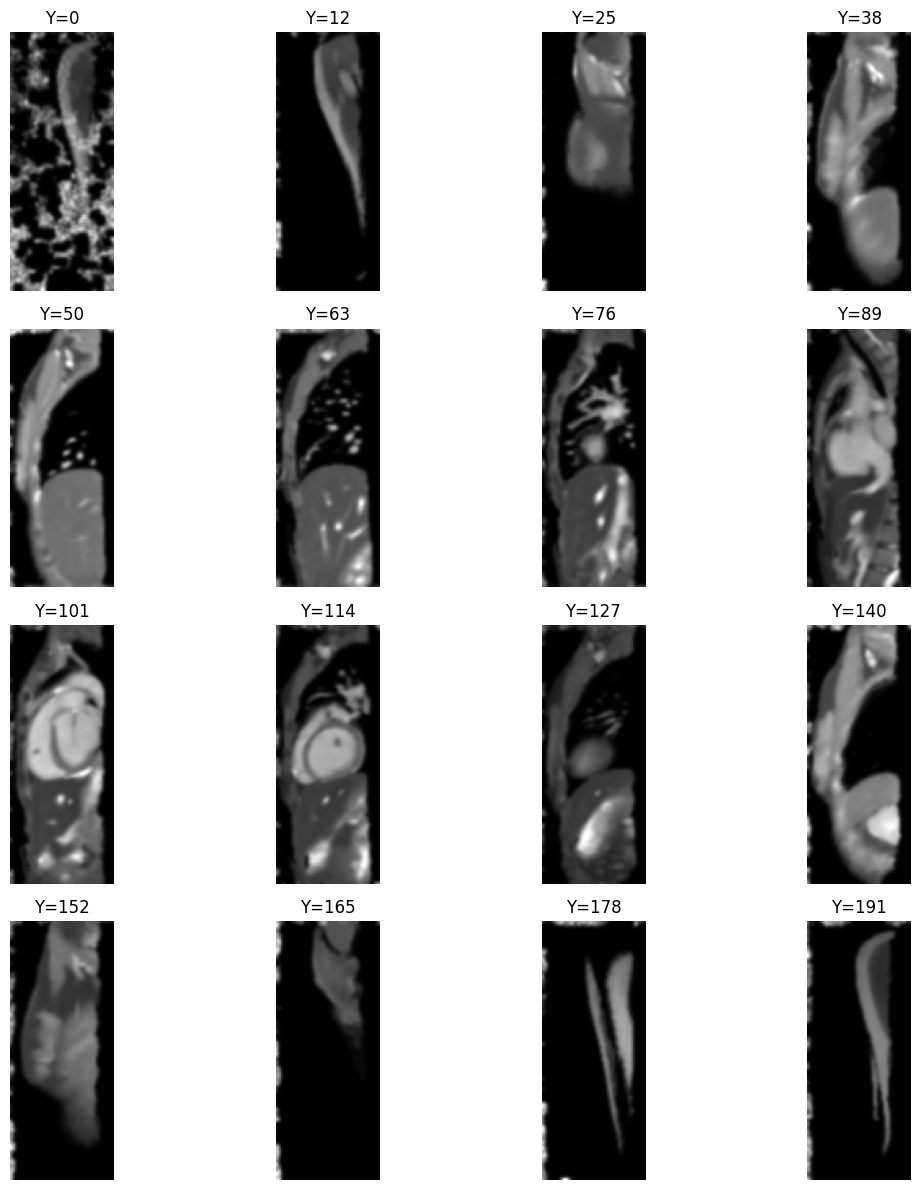

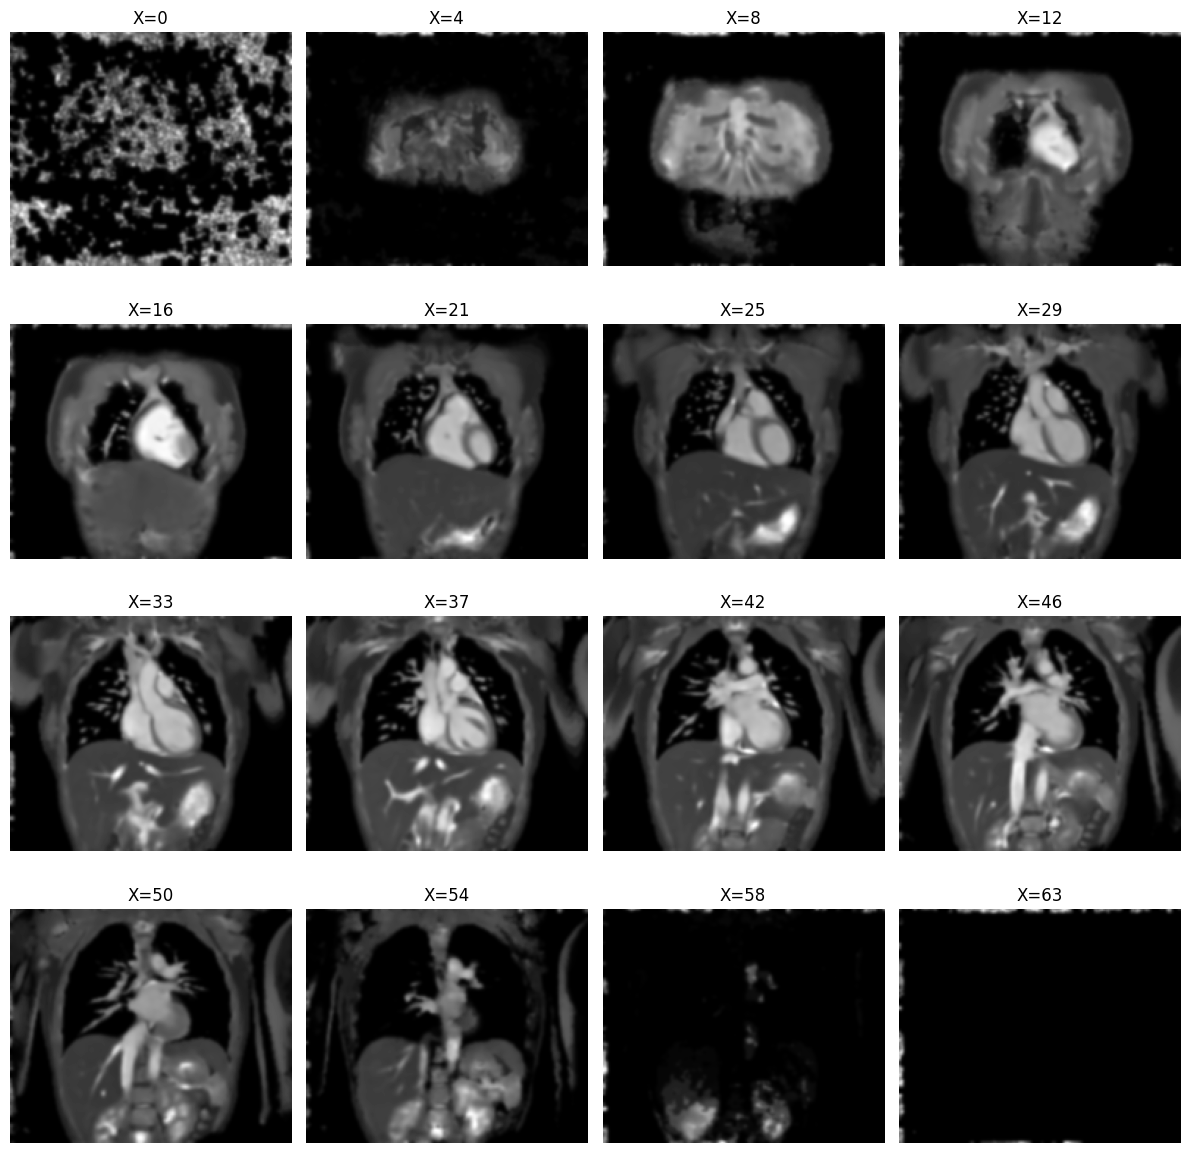

LANDMARKS
Base : [ 45. 114.  33.]
Apex : [ 95. 114.  33.]


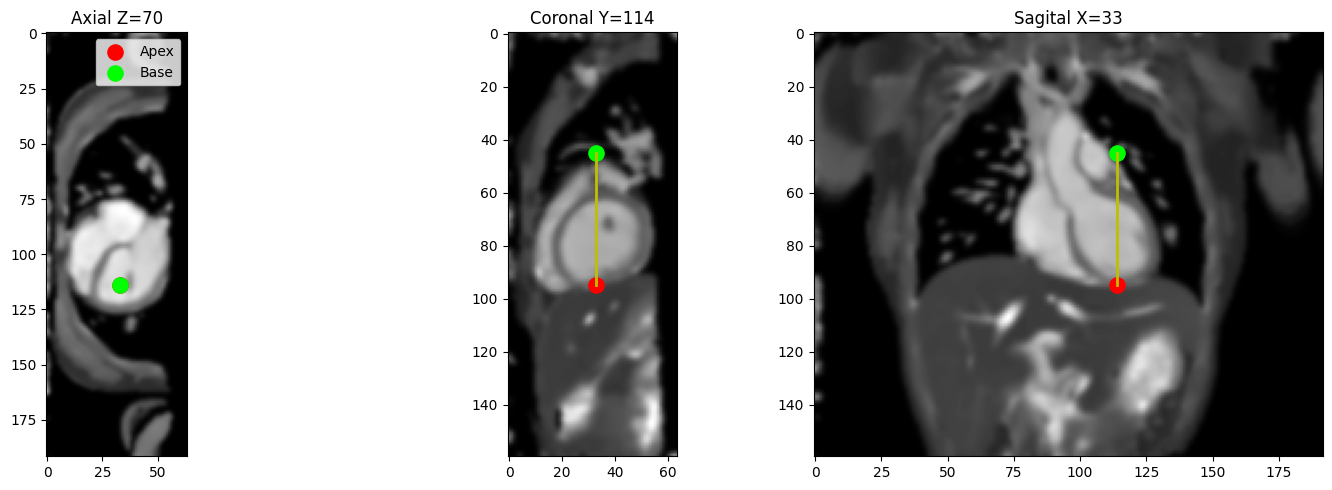

EJE LARGO
[-1.  0.  0.]
ORTOGONALIDAD
dot(eje,u): 0.0
dot(eje,v): 0.0
dot(u,v): 0.0
GENERANDO SAX


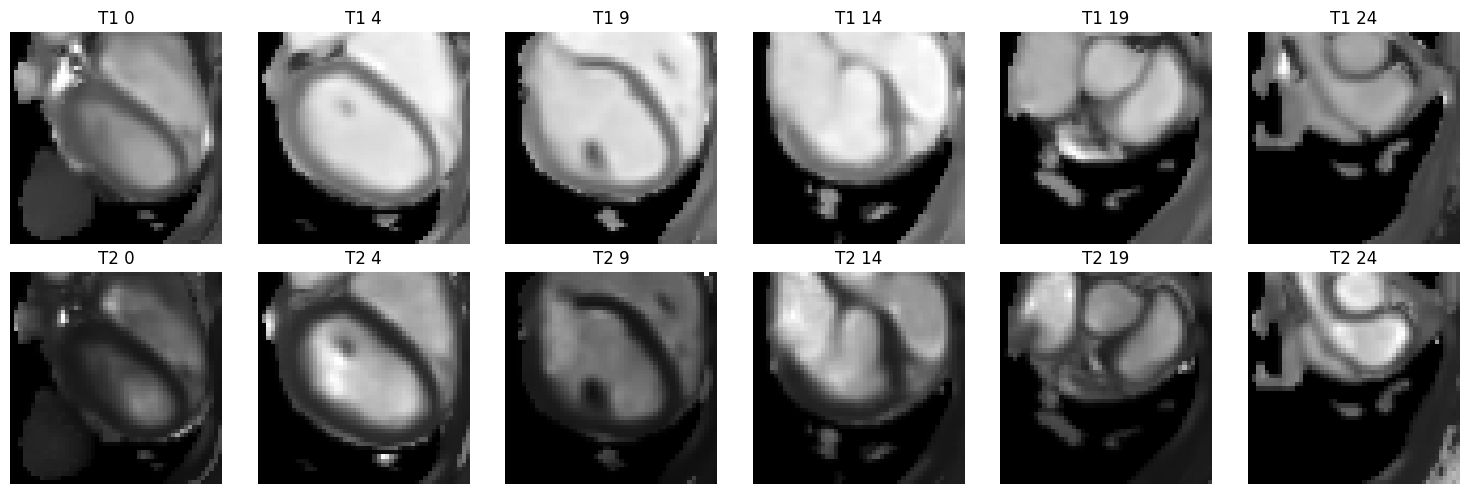

PIPELINE FINALIZADO


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import json

from scipy.ndimage import (
    gaussian_filter,
    sobel,
    map_coordinates
)

# =========================================================
# 1. CARGA
# =========================================================

t1 = np.load("mapa_T1.npy")
t2 = np.load("mapa_T2.npy")

t1 = np.nan_to_num(t1, nan=0.0)
t2 = np.nan_to_num(t2, nan=0.0)

print("===================================")
print("DATOS CARGADOS")
print("===================================")

print("Shape:", t1.shape)

# =========================================================
# 2. SUAVIZADO
# =========================================================

sigma = 1.0

t1_smooth = gaussian_filter(
    t1,
    sigma=sigma
)

t2_smooth = gaussian_filter(
    t2,
    sigma=sigma
)

print("Suavizado aplicado.")

# =========================================================
# 3. VISUALIZACIÓN MULTIPLANAR
# =========================================================

mid_z = t1.shape[0] // 2
mid_y = t1.shape[1] // 2
mid_x = t1.shape[2] // 2

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

# ---------------------------------------------------------
# AXIAL
# ---------------------------------------------------------

axes[0,0].imshow(
    t1_smooth[mid_z,:,:],
    cmap='gray'
)

axes[0,0].set_title(
    f'Axial Z={mid_z}'
)

# ---------------------------------------------------------
# CORONAL
# ---------------------------------------------------------

axes[0,1].imshow(
    t1_smooth[:,mid_y,:],
    cmap='gray'
)

axes[0,1].set_title(
    f'Coronal Y={mid_y}'
)

# ---------------------------------------------------------
# SAGITAL
# ---------------------------------------------------------

axes[0,2].imshow(
    t1_smooth[:,:,mid_x],
    cmap='gray'
)

axes[0,2].set_title(
    f'Sagital X={mid_x}'
)

# =========================================================
# 4. GRADIENTES
# =========================================================

gx = sobel(
    t1_smooth[mid_z],
    axis=0
)

gy = sobel(
    t1_smooth[mid_z],
    axis=1
)

gradiente = np.sqrt(
    gx**2 + gy**2
)

axes[1,0].imshow(
    gradiente,
    cmap='hot'
)

axes[1,0].set_title(
    'Gradiente axial'
)

# ---------------------------------------------------------
# CORONAL EXTRA
# ---------------------------------------------------------

axes[1,1].imshow(
    t1_smooth[:,mid_y,:],
    cmap='gray'
)

axes[1,1].set_title(
    'Usar para eje largo'
)

# ---------------------------------------------------------
# SAGITAL EXTRA
# ---------------------------------------------------------

axes[1,2].imshow(
    t1_smooth[:,:,mid_x],
    cmap='gray'
)

axes[1,2].set_title(
    'Usar para apex/base'
)

plt.tight_layout()
plt.show()
# =========================================================
# BUSQUEDA DEL CORAZON
# =========================================================

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12,12)
)

indices = np.linspace(
    0,
    t1.shape[0]-1,
    16,
    dtype=int
)

for ax, idx in zip(axes.ravel(), indices):

    ax.imshow(
        t1_smooth[idx],
        cmap='gray'
    )

    ax.set_title(f"Z={idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()
# =========================================================
# CORONAL
# =========================================================

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12,12)
)

indices = np.linspace(
    0,
    t1.shape[1]-1,
    16,
    dtype=int
)

for ax, idx in zip(axes.ravel(), indices):

    ax.imshow(
        t1_smooth[:,idx,:],
        cmap='gray'
    )

    ax.set_title(f"Y={idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()
# =========================================================
# SAGITAL
# =========================================================

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12,12)
)

indices = np.linspace(
    0,
    t1.shape[2]-1,
    16,
    dtype=int
)

for ax, idx in zip(axes.ravel(), indices):

    ax.imshow(
        t1_smooth[:,:,idx],
        cmap='gray'
    )

    ax.set_title(f"X={idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# 5. LANDMARKS SEMI-MANUALES
# =========================================================

x_central = 33
y_central = 114

# Ajuste inicial basado en inspección visual
# Modificaremos después si el SAX sigue descentrado

p_base = np.array([
    45,
    y_central,
    x_central
], dtype=float)

p_apex = np.array([
    95,
    y_central,
    x_central
], dtype=float)

print("===================================")
print("LANDMARKS")
print("===================================")
print("Base :", p_base)
print("Apex :", p_apex)

# =========================================================
# 6. VALIDACIÓN LANDMARKS
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

# ---------------------------------------------------------
# AXIAL
# ---------------------------------------------------------

z = int((p_apex[0] + p_base[0]) / 2)

axes[0].imshow(
    t1_smooth[z],
    cmap='gray'
)

axes[0].scatter(
    p_apex[2],
    p_apex[1],
    c='red',
    s=120,
    label='Apex'
)

axes[0].scatter(
    p_base[2],
    p_base[1],
    c='lime',
    s=120,
    label='Base'
)

axes[0].plot(
    [p_apex[2], p_base[2]],
    [p_apex[1], p_base[1]],
    'y-',
    linewidth=2
)

axes[0].set_title(
    f'Axial Z={z}'
)

axes[0].legend()

# ---------------------------------------------------------
# CORONAL
# ---------------------------------------------------------

axes[1].imshow(
    t1_smooth[:, y_central, :],
    cmap='gray'
)

axes[1].scatter(
    p_apex[2],
    p_apex[0],
    c='red',
    s=120
)

axes[1].scatter(
    p_base[2],
    p_base[0],
    c='lime',
    s=120
)

axes[1].plot(
    [p_apex[2], p_base[2]],
    [p_apex[0], p_base[0]],
    'y-',
    linewidth=2
)

axes[1].set_title(
    f'Coronal Y={y_central}'
)

# ---------------------------------------------------------
# SAGITAL
# ---------------------------------------------------------

axes[2].imshow(
    t1_smooth[:, :, x_central],
    cmap='gray'
)

axes[2].scatter(
    p_apex[1],
    p_apex[0],
    c='red',
    s=120
)

axes[2].scatter(
    p_base[1],
    p_base[0],
    c='lime',
    s=120
)

axes[2].plot(
    [p_apex[1], p_base[1]],
    [p_apex[0], p_base[0]],
    'y-',
    linewidth=2
)

axes[2].set_title(
    f'Sagital X={x_central}'
)

plt.tight_layout()
plt.show()

# =========================================================
# 7. EJE LARGO
# =========================================================

eje = p_base - p_apex

eje = eje / np.linalg.norm(eje)

print("===================================")
print("EJE LARGO")
print("===================================")
print(eje)

# =========================================================
# 8. BASE ORTONORMAL
# SIN p_lateral
# SIN GRAM SCHMIDT
# =========================================================

ref = np.array([1.0, 0.0, 0.0])

if abs(np.dot(eje, ref)) > 0.9:
    ref = np.array([0.0, 1.0, 0.0])

u = np.cross(
    eje,
    ref
)

u = u / np.linalg.norm(u)

v = np.cross(
    eje,
    u
)

v = v / np.linalg.norm(v)

print("===================================")
print("ORTOGONALIDAD")
print("===================================")

print("dot(eje,u):", np.dot(eje,u))
print("dot(eje,v):", np.dot(eje,v))
print("dot(u,v):", np.dot(u,v))
# =========================================================
# 9. REFORMATEO SAX
# =========================================================

def reformatear_sax(
    volumen,
    apex,
    base,
    eje,
    u,
    v,
    tamaño=50,
    nslices=25
):

    sax = np.zeros(
        (nslices, tamaño, tamaño)
    )

    half = tamaño // 2

    rango = np.linspace(
        -half,
        half,
        tamaño
    )

    UU, VV = np.meshgrid(
        rango,
        rango
    )

    longitud = np.linalg.norm(
        base - apex
    )

    offsets = np.linspace(
    0.10 * longitud,
    0.90 * longitud,
    nslices
)

    for i, d in enumerate(offsets):

        centro = apex + d * eje

        puntos = (
            centro[None,None,:]
            + UU[:,:,None] * u[None,None,:]
            + VV[:,:,None] * v[None,None,:]
        )

        coords = [
            puntos[:,:,0].ravel(),
            puntos[:,:,1].ravel(),
            puntos[:,:,2].ravel()
        ]

        valores = map_coordinates(
            volumen,
            coords,
            order=1,
            mode='constant',
            cval=0
        )

        sax[i] = valores.reshape(
            tamaño,
            tamaño
        )

    return sax

# =========================================================
# 10. GENERAR SAX
# =========================================================

print("===================================")
print("GENERANDO SAX")
print("===================================")

t1_sax = reformatear_sax(
    t1,
    p_apex,
    p_base,
    eje,
    u,
    v,
    tamaño=50,
    nslices=25
)

t2_sax = reformatear_sax(
    t2,
    p_apex,
    p_base,
    eje,
    u,
    v,
    tamaño=50,
    nslices=25
)

# =========================================================
# 11. VISUALIZACIÓN SAX
# =========================================================

nslices_reales = t1_sax.shape[0]

indices = np.linspace(
    0,
    nslices_reales-1,
    6,
    dtype=int
)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(15,5)
)

for j, idx in enumerate(indices):

    axes[0,j].imshow(
        t1_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[0,j].axis('off')

    axes[0,j].set_title(
        f"T1 {idx}"
    )

    axes[1,j].imshow(
        t2_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[1,j].axis('off')

    axes[1,j].set_title(
        f"T2 {idx}"
    )

plt.tight_layout()

plt.savefig(
    "preview_SAX.png",
    dpi=300
)

plt.show()

# =========================================================
# 12. EXPORTACIÓN
# =========================================================

np.save(
    "mapa_T1_SAX.npy",
    t1_sax
)

np.save(
    "mapa_T2_SAX.npy",
    t2_sax
)

# =========================================================
# 13. METADATA
# =========================================================

metadata = {

    "metodologia":
    "Pipeline semi-manual de reformateo SAX",

    "apex":
    p_apex.tolist(),

    "base":
    p_base.tolist(),

    "eje_largo":
    eje.tolist(),

    "vector_u":
    u.tolist(),

    "vector_v":
    v.tolist(),

    "sigma_gaussiano":
    sigma,

    "nslices":
    int(nslices_reales),

    "slice_size":
    int(t1_sax.shape[1])
}
print("===================================")
print("PIPELINE FINALIZADO")
print("===================================")